Install and import libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_recall_curve



Loading dataset

In [2]:
df = pd.read_csv('Iris.csv')
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


Understanding the data

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Data cleaning

In [4]:
## checking for duplicates
print('== Duplicate Values ==')
print (df.duplicated().sum())

## checking for missing values
print('== Missing Values ==')
df.isnull().sum()

== Duplicate Values ==
0
== Missing Values ==


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

EDA

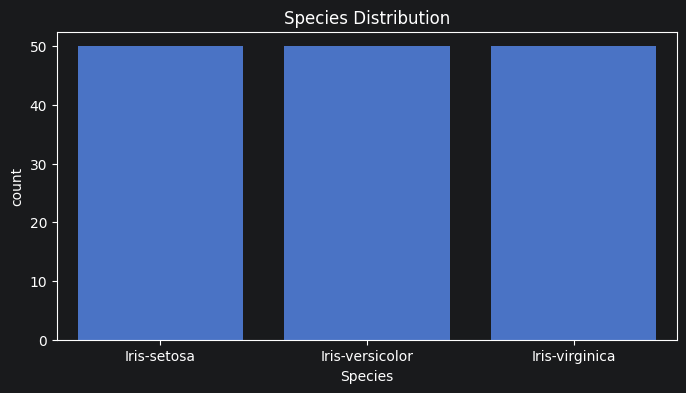

The flower species are equally distributed


In [5]:
## Distribution of data
plt.figure(figsize=(8,4))
sns.countplot(x = 'Species', data = df)
plt.title('Species Distribution')
plt.show()
print('The flower species are equally distributed')


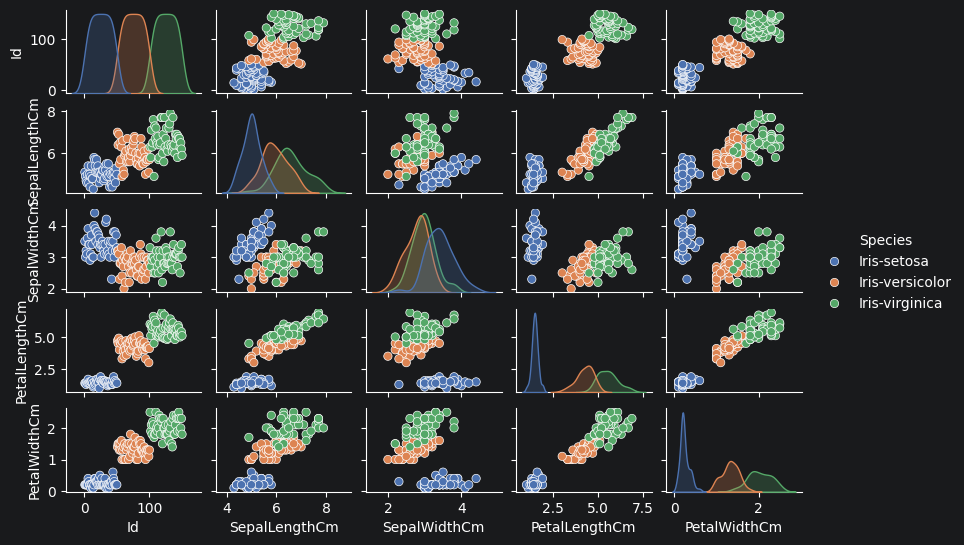

Interpretation: Iris-setosa shows a distinct characteristic from the others as shown in the clusters formed, Petal length and width is most effective in distinguishing species. Strong correlation between petal length and width, as one increases the other also increases. There are some overlap in the measurement of some species especially with Sepal length and width, making it difficult to distinguish them using only sepal measurements.


In [6]:
## Correlation of numerical features
sns.pairplot(df, hue='Species', height=1.1, aspect=1.5, palette='deep', diag_kind='kde')
plt.show()
print('Interpretation: Iris-setosa shows a distinct characteristic from the others as shown in the clusters formed, Petal length and width is most effective in distinguishing species. Strong correlation between petal length and width, as one increases the other also increases. There are some overlap in the measurement of some species especially with Sepal length and width, making it difficult to distinguish them using only sepal measurements.')

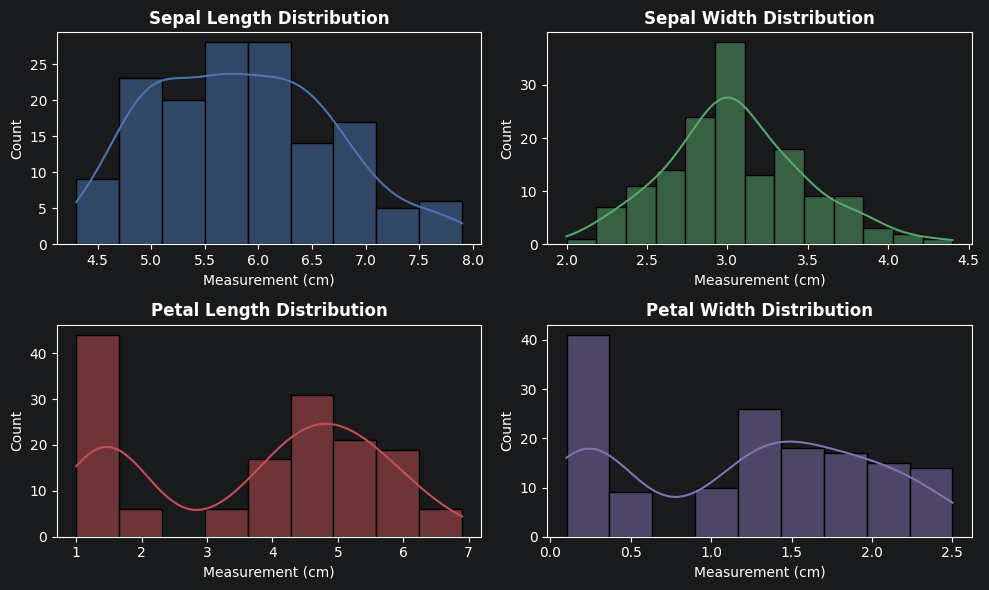

Interpretation:
Sepal Length Distribution: This shows a relatively symmetric and bell-shaped normal distribution, most of the flowers have sepal length between 5.0cm and 6.5cm, with the peak at 5.8cm.
Sepal Width Distribution: This shows a strong narrow normal distribution, they cluster tightly around the center, with majority between 2.8 and 3.4cm, with a clear distinct peak at 3cm.
Petal Length Distribution: This shows a bimodal distribution, one sharp isolated peak on the left around 1.5cm and a broader peak on the right between 4.0 and 5.5cm. This gap exists because one specie-Iris setosa has much smaller petals than others.
Petal Width Distribution: Same as the petal length, one peak on the left between 0.2 and 0.4cm and the second wider peaks around 1.3 and 1.8cm.


In [7]:
## Distribution of the data
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Define colors for each feature plot
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
titles = [
    "Sepal Length Distribution",
    "Sepal Width Distribution",
    "Petal Length Distribution",
    "Petal Width Distribution",
]

# Loop through features and plot histograms
for i, ax in enumerate(axes.flat):
    sns.histplot(
        data=df,
        x=features[i],
        color=colors[i],
        kde=True,
        ax=ax,
        edgecolor="black",
    )
    ax.set_title(titles[i], fontsize=12, fontweight="bold")
    ax.set_xlabel("Measurement (cm)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print('Interpretation:')
print('Sepal Length Distribution: This shows a relatively symmetric and bell-shaped normal distribution, most of the flowers have sepal length between 5.0cm and 6.5cm, with the peak at 5.8cm.')
print('Sepal Width Distribution: This shows a strong narrow normal distribution, they cluster tightly around the center, with majority between 2.8 and 3.4cm, with a clear distinct peak at 3cm.')

print('Petal Length Distribution: This shows a bimodal distribution, one sharp isolated peak on the left around 1.5cm and a broader peak on the right between 4.0 and 5.5cm. This gap exists because one specie-Iris setosa has much smaller petals than others.')
print('Petal Width Distribution: Same as the petal length, one peak on the left between 0.2 and 0.4cm and the second wider peaks around 1.3 and 1.8cm.')

Feature Selection

In [8]:
x=df.drop(['Id', 'Species'], axis=1)
y= df['Species']

Train-Test Split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, stratify=y, random_state=42)
print('Features shape:', x_train.shape)
print('Labels shape:', y_train.shape)
print(y_train.value_counts())

Features shape: (105, 4)
Labels shape: (105,)
Species
Iris-versicolor    35
Iris-setosa        35
Iris-virginica     35
Name: count, dtype: int64


Models Training

In [38]:
# Training LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
# Training RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Predictions

In [11]:
# Predicting using logisticregression
y_pred_lr = lr.predict(x_test)

# Predicting using randomforestclassifier
y_pred_rf = rf.predict(x_test)

# Displaying predictions and actual
pred_lr_df = pd.DataFrame(y_pred_lr, columns = ['lr_Predicted'])
pred_rf_df = pd.DataFrame(y_pred_rf, columns = ['rf_Predicted'])
y_test_df = pd.DataFrame(y_test).reset_index(drop = True)
results = pd.concat([y_test_df, pred_lr_df, pred_rf_df], axis = 1)
print("Model Predictions vs Actual:")
display(results.head(10))

Model Predictions vs Actual:


,Species,lr_Predicted,rf_Predicted
0,Iris-virginica,Iris-virginica,Iris-virginica
1,Iris-versicolor,Iris-versicolor,Iris-versicolor
2,Iris-virginica,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor,Iris-versicolor
4,Iris-virginica,Iris-virginica,Iris-virginica
5,Iris-virginica,Iris-virginica,Iris-virginica
6,Iris-versicolor,Iris-versicolor,Iris-versicolor
7,Iris-versicolor,Iris-versicolor,Iris-versicolor
8,Iris-setosa,Iris-setosa,Iris-setosa
9,Iris-virginica,Iris-virginica,Iris-virginica


Models Validation

In [17]:
# Configure and run cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
score1 = cross_val_score(lr, x_train, y_train, cv=kfold, scoring='accuracy')
score2 = cross_val_score(rf, x_train, y_train, cv=kfold, scoring='accuracy')

print(f"Mean Accuracy1: {np.mean(score1):.4f}")
print(f"Mean Accuracy2: {np.mean(score2):.4f}")
print(f"LogisticRegression model achieved a slightly better performance than RandomForestClassifier")


Mean Accuracy1: 0.9714
Mean Accuracy2: 0.9619
LogisticRegression model achieved a slightly better performance than RandomForestClassifier


Models Evaluation

In [21]:
y_true=y_test
y_pred_lr = lr.predict(x_test)
y_pred_rf = rf.predict(x_test)

# LogisticRegression Evaluation
accuracy_lr=accuracy_score(y_true, y_pred_lr)
class_report_lr=classification_report(y_true, y_pred_lr)
conf_matrix_lr=confusion_matrix(y_true,y_pred_lr)

print('=== LogisticRegression ===')
print(f'Overall Model Accuracy: {accuracy_lr * 100:.2f}%')
print(f'Classification Report: \n{class_report_lr}')
print(f'Confusion Matrix: \n{conf_matrix_lr}')


# RandomForestClassifier Evaluation
accuracy_rf=accuracy_score(y_true, y_pred_rf)
class_report_rf=classification_report(y_true, y_pred_rf)
conf_matrix_rf=confusion_matrix(y_true,y_pred_rf)

print('=== RandomForestClassifier ===')
print(f'Overall Model Accuracy: {accuracy_rf * 100:.2f}%')
print(f'Classification Report: \n{class_report_rf}')
print(f'Confusion Matrix: \n{conf_matrix_rf}')

=== LogisticRegression ===
Overall Model Accuracy: 93.33%
Classification Report: 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.93      0.87      0.90        15

       accuracy                           0.93        45
      macro avg       0.93      0.93      0.93        45
   weighted avg       0.93      0.93      0.93        45

Confusion Matrix: 
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]
=== RandomForestClassifier ===
Overall Model Accuracy: 88.89%
Classification Report: 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.78      0.93      0.85        15
 Iris-virginica       0.92      0.73      0.81        15

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90    

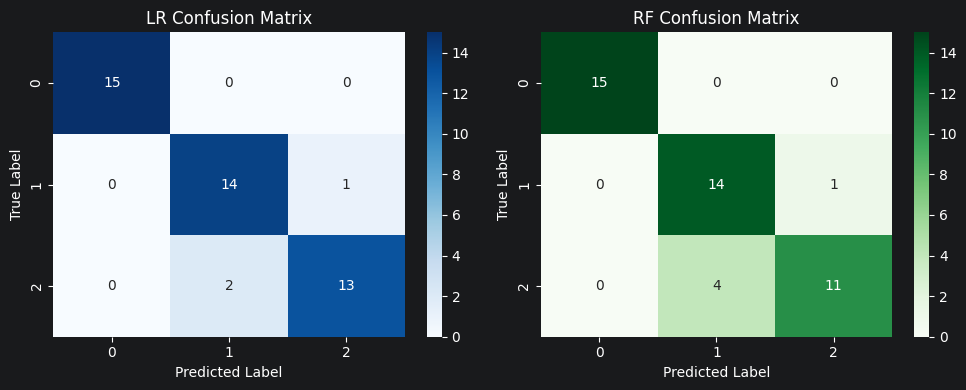

LR Confusion Matrix: The model correctly classified Iris-setosa species, misclassified 1 instance of Iris-versicolor as Iris-virginica, also misclassified 2 instances of Iris-virginica as Iris-versicolor.
RF Confusion Matrix: The model correctly classified Iris-setosa species, misclassified 1 instance of Iris-versicolor as Iris-virginica, also misclassified 4 instances of Iris-virginica as Iris-versicolor. 
The confusion matrix shows that LogisticRegression has a better performance than RandomForestClassifier.


In [37]:
# Visualize the confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(conf_matrix_lr, annot=True, fmt="d", cmap="Blues", xticklabels=True, yticklabels=True, ax=axes[0])
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].set_title('LR Confusion Matrix')

sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Greens", xticklabels=True, yticklabels=True)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].set_title('RF Confusion Matrix')

# Displlay the figures
plt.tight_layout()
plt.show()

print('LR Confusion Matrix: The model correctly classified Iris-setosa species, misclassified 1 instance of Iris-versicolor as Iris-virginica, also misclassified 2 instances of Iris-virginica as Iris-versicolor.')
print('RF Confusion Matrix: The model correctly classified Iris-setosa species, misclassified 1 instance of Iris-versicolor as Iris-virginica, also misclassified 4 instances of Iris-virginica as Iris-versicolor. ')
print('The confusion matrix shows that LogisticRegression has a better performance than RandomForestClassifier.')